# LSTM Model (Deep Learning Model)

In [4]:
import pandas as pd

# सही तरीका
y_train = pd.read_csv(r"C:\Users\anagh\OneDrive\Desktop\DUK\PA\Project1\ucihar-dataset\UCI-HAR Dataset\train\y_train.txt", header=None)
y_test = pd.read_csv(r"C:\Users\anagh\OneDrive\Desktop\DUK\PA\Project1\ucihar-dataset\UCI-HAR Dataset\test\y_test.txt", header=None)

# Convert to numpy
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

# Convert to integer
y_train = y_train.astype(int)
y_test = y_test.astype(int)

# Adjust labels (1–6 → 0–5)
y_train = y_train - 1
y_test = y_test - 1

print(y_train[:5])

[4 4 4 4 4]


In [5]:
import numpy as np

In [6]:
def load_signal(file):
    return pd.read_csv(file, sep='\s+', header=None).values

X_train_signal = np.array([
    load_signal(r"C:\Users\anagh\OneDrive\Desktop\DUK\PA\Project1\ucihar-dataset\UCI-HAR Dataset\train\Inertial Signals\body_acc_x_train.txt"),
    load_signal(r"C:\Users\anagh\OneDrive\Desktop\DUK\PA\Project1\ucihar-dataset\UCI-HAR Dataset\train\Inertial Signals\body_acc_y_train.txt"),
    load_signal(r"C:\Users\anagh\OneDrive\Desktop\DUK\PA\Project1\ucihar-dataset\UCI-HAR Dataset\train\Inertial Signals\body_acc_z_train.txt"),
    load_signal(r"C:\Users\anagh\OneDrive\Desktop\DUK\PA\Project1\ucihar-dataset\UCI-HAR Dataset\train\Inertial Signals\body_gyro_x_train.txt"),
    load_signal(r"C:\Users\anagh\OneDrive\Desktop\DUK\PA\Project1\ucihar-dataset\UCI-HAR Dataset\train\Inertial Signals\body_gyro_y_train.txt"),
    load_signal(r"C:\Users\anagh\OneDrive\Desktop\DUK\PA\Project1\ucihar-dataset\UCI-HAR Dataset\train\Inertial Signals\body_gyro_z_train.txt")
]).transpose(1,2,0)

X_test_signal = np.array([
    load_signal(r"C:\Users\anagh\OneDrive\Desktop\DUK\PA\Project1\ucihar-dataset\UCI-HAR Dataset\test\Inertial Signals\body_acc_x_test.txt"),
    load_signal(r"C:\Users\anagh\OneDrive\Desktop\DUK\PA\Project1\ucihar-dataset\UCI-HAR Dataset\test\Inertial Signals\body_acc_y_test.txt"),
    load_signal(r"C:\Users\anagh\OneDrive\Desktop\DUK\PA\Project1\ucihar-dataset\UCI-HAR Dataset\test\Inertial Signals\body_acc_z_test.txt"),
    load_signal(r"C:\Users\anagh\OneDrive\Desktop\DUK\PA\Project1\ucihar-dataset\UCI-HAR Dataset\test\Inertial Signals\body_gyro_x_test.txt"),
    load_signal(r"C:\Users\anagh\OneDrive\Desktop\DUK\PA\Project1\ucihar-dataset\UCI-HAR Dataset\test\Inertial Signals\body_gyro_y_test.txt"),
    load_signal(r"C:\Users\anagh\OneDrive\Desktop\DUK\PA\Project1\ucihar-dataset\UCI-HAR Dataset\test\Inertial Signals\body_gyro_z_test.txt")
]).transpose(1,2,0)

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(64, input_shape=(X_train_signal.shape[1], X_train_signal.shape[2])),
    Dense(64, activation='relu'),
    Dense(6, activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 64)                18176     
                                                                 
 dense (Dense)               (None, 64)                4160      
                                                                 
 dense_1 (Dense)             (None, 6)                 390       
                                                                 
Total params: 22726 (88.77 KB)
Trainable params: 22726 (88.77 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [8]:
history = model.fit(
    X_train_signal, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
92/92 [==============================] - 13s 105ms/step - loss: 1.4756 - accuracy: 0.3338 - val_loss: 1.1676 - val_accuracy: 0.3542
Epoch 2/10
92/92 [==============================] - 9s 97ms/step - loss: 1.0883 - accuracy: 0.4278 - val_loss: 1.0479 - val_accuracy: 0.4392
Epoch 3/10
92/92 [==============================] - 9s 97ms/step - loss: 0.9479 - accuracy: 0.4962 - val_loss: 0.9100 - val_accuracy: 0.5235
Epoch 4/10
92/92 [==============================] - 9s 97ms/step - loss: 0.8852 - accuracy: 0.5322 - val_loss: 0.8228 - val_accuracy: 0.5738
Epoch 5/10
92/92 [==============================] - 9s 97ms/step - loss: 0.8617 - accuracy: 0.5467 - val_loss: 0.7745 - val_accuracy: 0.5962
Epoch 6/10
92/92 [==============================] - 9s 95ms/step - loss: 0.8020 - accuracy: 0.5718 - val_loss: 0.7189 - val_accuracy: 0.5901
Epoch 7/10
92/92 [==============================] - 9s 96ms/step - loss: 0.8648 - accuracy: 0.5763 - val_loss: 0.7101 - val_accuracy: 0.6050
Epoch 8/10


In [9]:
model.save("har_lstm_model.h5")

c:\Users\anagh\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [10]:
loss, acc = model.evaluate(X_test_signal, y_test)

print("\n--- LSTM RESULTS ---")
print("Accuracy:", acc)

93/93 [==============================] - 2s 25ms/step - loss: 0.7239 - accuracy: 0.6064

--- LSTM RESULTS ---
Accuracy: 0.6063793897628784


In [11]:
import matplotlib.pyplot  as plt

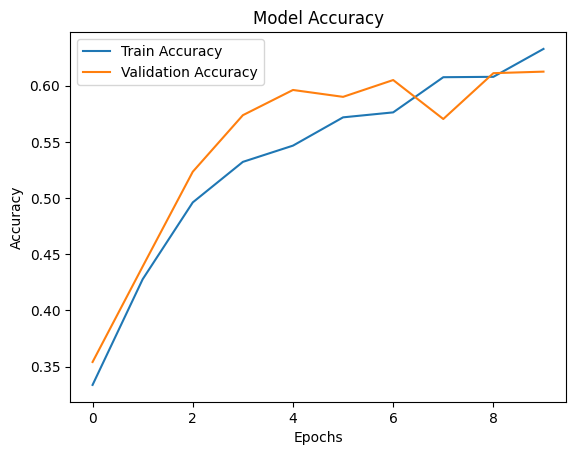

In [13]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.legend()
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()